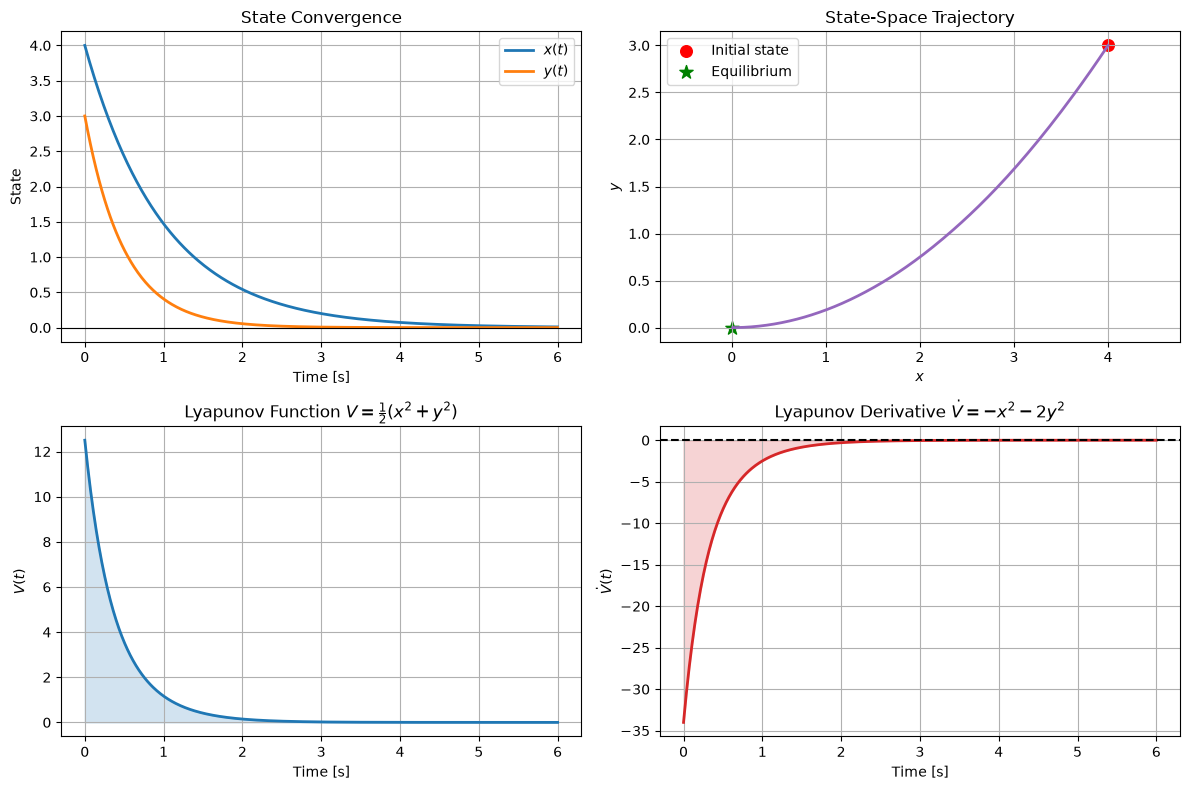

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --------------------------------------------------
# 1. Stable system
#    dx/dt = -x
#    dy/dt = -2y
# --------------------------------------------------
def system(t, state):
    x, y = state
    return [-x, -2 * y]


# --------------------------------------------------
# 2. Lyapunov function
#    V(x, y) = 1/2(x^2 + y^2)
# --------------------------------------------------
def lyapunov(x, y):
    return 0.5 * (x**2 + y**2)


# --------------------------------------------------
# 3. Simulation
# --------------------------------------------------
initial_state = [4.0, 3.0]
t_eval = np.linspace(0, 6, 500)

solution = solve_ivp(
    system,
    t_span=(0, 6),
    y0=initial_state,
    t_eval=t_eval
)

x_trajectory = solution.y[0]
y_trajectory = solution.y[1]
V_trajectory = lyapunov(x_trajectory, y_trajectory)


# --------------------------------------------------
# 4. Create the Lyapunov surface
# --------------------------------------------------
x_surface = np.linspace(-5, 5, 150)
y_surface = np.linspace(-5, 5, 150)

X, Y = np.meshgrid(x_surface, y_surface)
V = lyapunov(X, Y)


# --------------------------------------------------
# 5. 3D visualization
# --------------------------------------------------
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

# Lyapunov surface
surface = ax.plot_surface(
    X,
    Y,
    V,
    cmap="viridis",
    alpha=0.65,
    edgecolor="none"
)

# System trajectory on the Lyapunov surface
ax.plot(
    x_trajectory,
    y_trajectory,
    V_trajectory,
    color="red",
    linewidth=3,
    label="System trajectory"
)

# Initial state
ax.scatter(
    x_trajectory[0],
    y_trajectory[0],
    V_trajectory[0],
    color="orange",
    edgecolor="black",
    s=100,
    label="Initial state"
)

# Equilibrium point
ax.scatter(
    0,
    0,
    0,
    color="lime",
    edgecolor="black",
    marker="*",
    s=250,
    label="Stable equilibrium"
)

ax.set_title(
    r"3D Lyapunov Function: $V(x,y)=\frac{1}{2}(x^2+y^2)$",
    fontsize=15
)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$V(x,y)$")

ax.view_init(elev=30, azim=45)
ax.legend()

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label=r"$V(x,y)$"
)

plt.tight_layout()
plt.show()